In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

In [2]:
uploaded = files.upload()

Saving IMG_0665.jpeg to IMG_0665 (1).jpeg


In [3]:
# Membaca citra dan ubah ke grayscale
img = Image.open(list(uploaded.keys())[0]).convert('L')
img = np.array(img)

In [4]:
# 1. Menghitung Histogram Asli
hist = np.zeros(256)
for pixel in img.flatten():
    hist[pixel] += 1

In [5]:
# 2. Normalisasi Histogram
total_pixels = img.size
hist_norm = hist / total_pixels

In [6]:
# 3. Menghitung CDF
cdf = np.zeros(256)
cdf[0] = hist_norm[0]
for i in range(1, 256):
    cdf[i] = cdf[i-1] + hist_norm[i]

In [7]:
# 4. Histogram Equalization
L = 256
mapping = np.floor((L-1) * cdf).astype('uint8')
img_equalized = mapping[img]

# Histogram setelah equalization
hist_eq = np.zeros(256)
for pixel in img_equalized.flatten():
    hist_eq[pixel] += 1

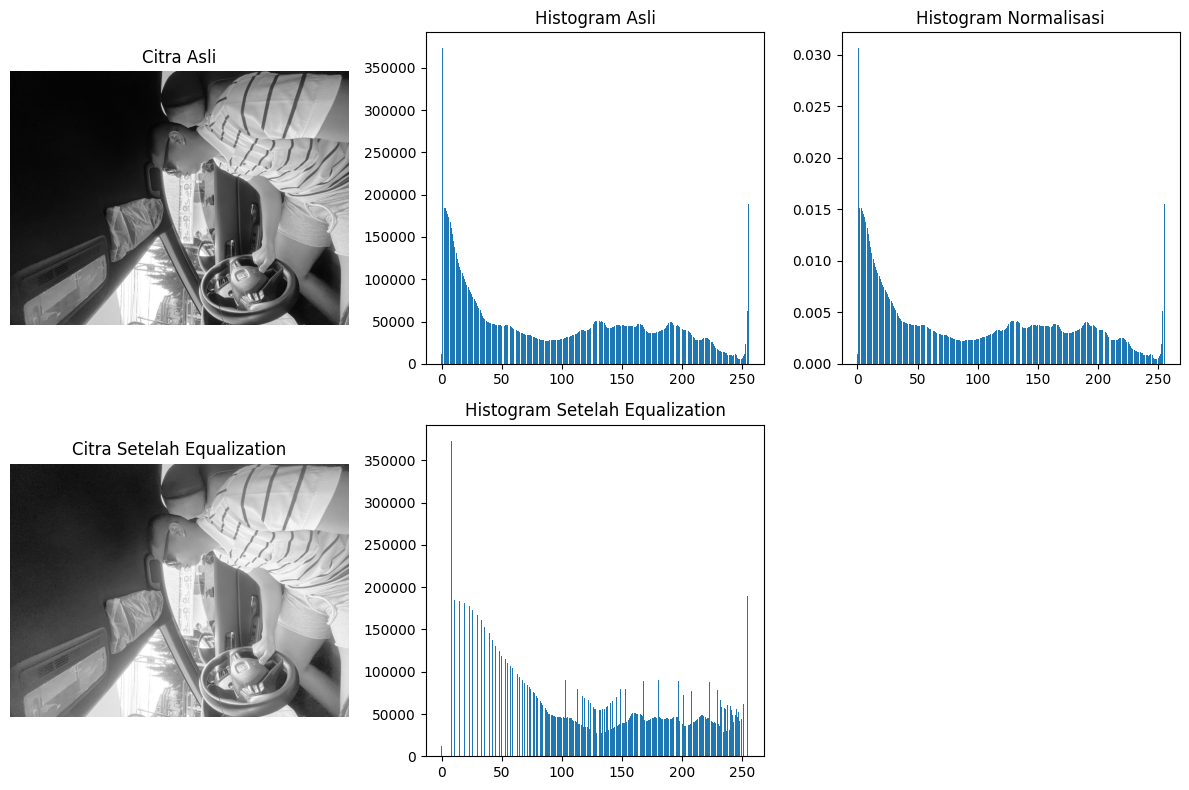

In [8]:
# 5. Visualisasi Hasil
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Citra Asli")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Histogram Asli")
plt.bar(range(256), hist)

plt.subplot(2,3,3)
plt.title("Histogram Normalisasi")
plt.bar(range(256), hist_norm)

plt.subplot(2,3,4)
plt.title("Citra Setelah Equalization")
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Histogram Setelah Equalization")
plt.bar(range(256), hist_eq)

plt.tight_layout()
plt.show()